<a href="https://colab.research.google.com/github/Aboudzito/ML-LR-KNN-Random-Forest-DL/blob/main/%22Easy_pizza%22_Final_project_level_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📂 Step 1: Load and Understand the Data

In [166]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

In [167]:
df = pd.read_csv('/content/easy_pizza_sales.csv')
df.head()

,order_id,pizza_name_id,quantity,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,hawaiian_m,1,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,classic_dlx_m,1,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,2,five_cheese_l,1,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,2,ital_supr_l,1,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,2,mexicana_m,1,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [168]:
df.tail()

,order_id,pizza_name_id,quantity,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
48615,21348,ckn_alfredo_m,1,16.75,16.75,M,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",The Chicken Alfredo Pizza
48616,21348,four_cheese_l,1,17.95,17.95,L,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",The Four Cheese Pizza
48617,21348,napolitana_s,1,12.00,12.00,S,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",The Napolitana Pizza
48618,21349,mexicana_l,1,20.25,20.25,L,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
48619,21350,bbq_ckn_s,1,12.75,12.75,S,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",The Barbecue Chicken Pizza


In [169]:
df.keys()

Index(['order_id', 'pizza_name_id', 'quantity', 'unit_price', 'total_price',
       'pizza_size', 'pizza_category', 'pizza_ingredients', 'pizza_name'],
      dtype='object')

In [170]:
df.describe()

,order_id,quantity,unit_price,total_price
count,48620.000000,48620.000000,48620.000000,48620.000000
mean,10701.479761,1.019622,16.494132,16.821474
std,6180.119770,0.143077,3.621789,4.437398
min,1.000000,1.000000,9.750000,9.750000
25%,5337.000000,1.000000,12.750000,12.750000
50%,10682.500000,1.000000,16.500000,16.500000
75%,16100.000000,1.000000,20.250000,20.500000
max,21350.000000,4.000000,35.950000,83.000000


In [171]:
df.duplicated().sum()

np.int64(0)



---



I prefer data exploring before data cleaning so i can understand the data even if i need to repeat the same process again

## 📊 Step 3: Data Exploration


In [172]:
print("Top 5 Most Ordered Pizzas:")
display(df.pizza_name.head())

Top 5 Most Ordered Pizzas:


,pizza_name
0,The Hawaiian Pizza
1,The Classic Deluxe Pizza
2,The Five Cheese Pizza
3,The Italian Supreme Pizza
4,The Mexicana Pizza


In [173]:
print("last 5 Pizzas orderd:")
display(df.tail())
print("number of pizzas orderd are: 48619	")

last 5 Pizzas orderd:


,order_id,pizza_name_id,quantity,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
48615,21348,ckn_alfredo_m,1,16.75,16.75,M,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",The Chicken Alfredo Pizza
48616,21348,four_cheese_l,1,17.95,17.95,L,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",The Four Cheese Pizza
48617,21348,napolitana_s,1,12.00,12.00,S,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",The Napolitana Pizza
48618,21349,mexicana_l,1,20.25,20.25,L,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
48619,21350,bbq_ckn_s,1,12.75,12.75,S,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",The Barbecue Chicken Pizza


number of pizzas orderd are: 48619	


In [174]:
print("Most orderd pizza size:")
display(df['pizza_size'].value_counts())
print("The most orderd pizza is: Large")

Most orderd pizza size:


,count
pizza_size,
L,18519
M,15379
S,14132
XL,544
XXL,28


The most orderd pizza is: Large


In [175]:
print("Most sold pizza category:")
display(df['pizza_category'].value_counts())
print("The most sold pizza category is: Classic")

Most sold pizza category:


,count
pizza_category,
Classic,14575
Supreme,11776
Veggie,11448
Chicken,10812


The most sold pizza category is: Classic


In [176]:
overall_revenue = df['total_price'].sum()
print(f"Overall Revenue: ${overall_revenue:}")

Overall Revenue: $817860.05


In [177]:
revenue_per_pizza = df.groupby('pizza_name')['total_price'].sum()
most_revenue_pizzas = revenue_per_pizza.sort_values(ascending=False)
print("Top 10 Most Revenue Generating Pizzas:")
display(most_revenue_pizzas.head(10))
print("The most revenue generating pizza is: The Thai Chicken Pizza")

Top 10 Most Revenue Generating Pizzas:


,total_price
pizza_name,
The Thai Chicken Pizza,43434.25
The Barbecue Chicken Pizza,42768.00
The California Chicken Pizza,41409.50
The Classic Deluxe Pizza,38180.50
The Spicy Italian Pizza,34831.25
The Southwest Chicken Pizza,34705.75
The Italian Supreme Pizza,33476.75
The Hawaiian Pizza,32273.25
The Four Cheese Pizza,32265.70


The most revenue generating pizza is: The Thai Chicken Pizza


## 🧹 Step 2: Data Cleaning

In [178]:
df.isna().sum()

,0
order_id,0
pizza_name_id,0
quantity,0
unit_price,0
total_price,0
pizza_size,18
pizza_category,9
pizza_ingredients,11
pizza_name,0


In [179]:
df.nunique()

,0
order_id,21350
pizza_name_id,91
quantity,4
unit_price,25
total_price,56
pizza_size,5
pizza_category,4
pizza_ingredients,32
pizza_name,32


In [180]:
df.value_counts(['pizza_size'])

,count
pizza_size,
L,18519
M,15379
S,14132
XL,544
XXL,28


In [181]:
df.isna().sum()

,0
order_id,0
pizza_name_id,0
quantity,0
unit_price,0
total_price,0
pizza_size,18
pizza_category,9
pizza_ingredients,11
pizza_name,0


In [182]:
df['expected total'] = df['quantity'] * df['unit_price']
diffrence = df['total_price'] != df['expected total']


In [183]:
diffrence.sum()

np.int64(0)

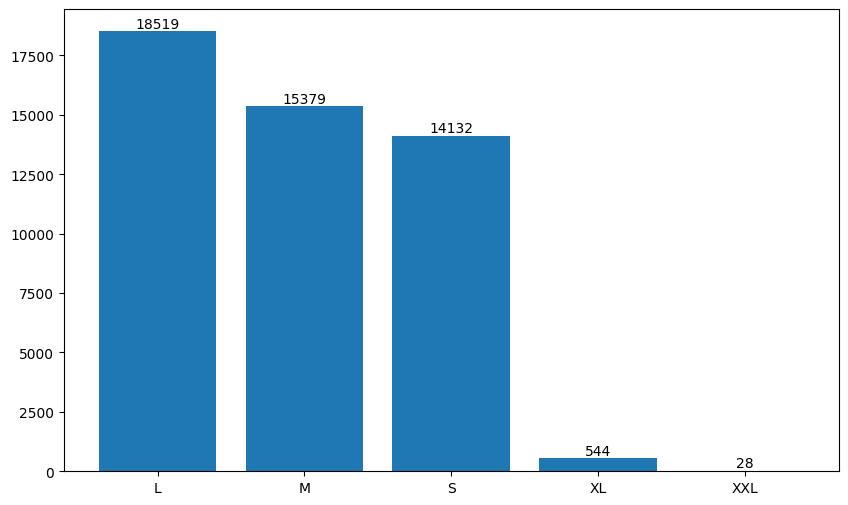

In [184]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = plt.bar(df['pizza_size'].value_counts().index, df['pizza_size'].value_counts().values)

# Add the count on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), va='bottom', ha='center')

In [185]:
category_revenue = df.groupby('pizza_category')['total_price'].sum()

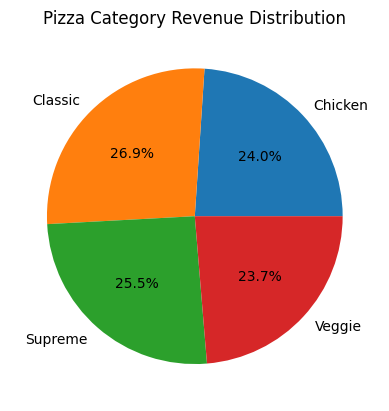

In [186]:
plt.pie(category_revenue, labels=category_revenue.index, autopct='%1.1f%%')
plt.title('Pizza Category Revenue Distribution')
plt.show()

In [187]:
revenue_over_time = df.groupby('order_id')['total_price'].sum()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


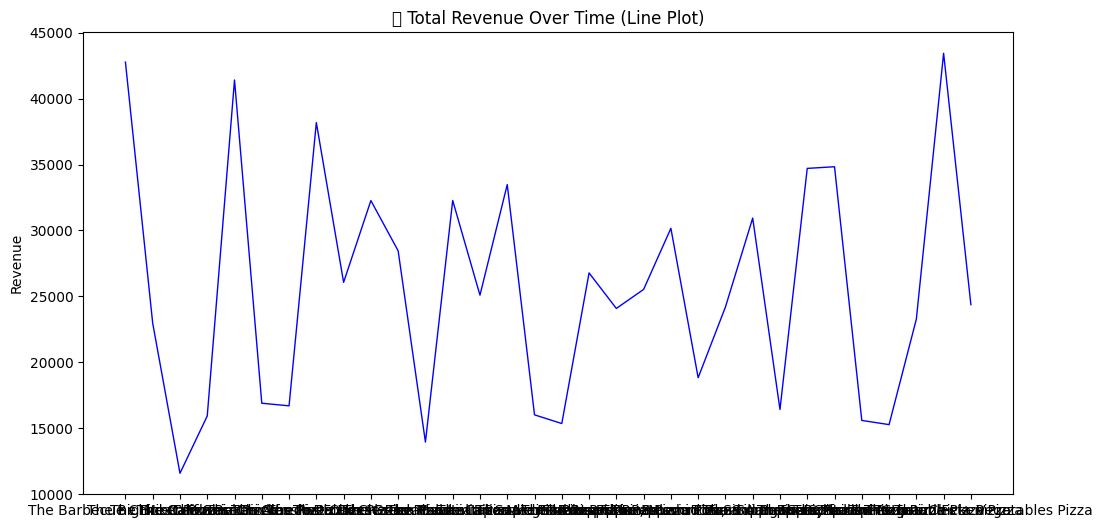

In [188]:
plt.figure(figsize=(12, 6))
plt.plot(revenue_per_pizza.index, revenue_per_pizza.values, color='blue', linewidth=1)
plt.title('📈 Total Revenue Over Time (Line Plot)')
plt.ylabel('Revenue')
plt.show()


In [189]:
revenue_per_pizza = df.groupby('pizza_name')['total_price'].sum()
most_revenue_pizzas = revenue_per_pizza.sort_values(ascending=False)
print("Top 10 Most Revenue Generating Pizzas:")
display(most_revenue_pizzas.head(10))
print("The most revenue generating pizza is: The Thai Chicken Pizza")

Top 10 Most Revenue Generating Pizzas:


,total_price
pizza_name,
The Thai Chicken Pizza,43434.25
The Barbecue Chicken Pizza,42768.00
The California Chicken Pizza,41409.50
The Classic Deluxe Pizza,38180.50
The Spicy Italian Pizza,34831.25
The Southwest Chicken Pizza,34705.75
The Italian Supreme Pizza,33476.75
The Hawaiian Pizza,32273.25
The Four Cheese Pizza,32265.70


The most revenue generating pizza is: The Thai Chicken Pizza


In [190]:
df.select_dtypes('number').corr()

,order_id,quantity,unit_price,total_price,expected total
order_id,1.000000,0.003621,-0.003323,-0.000889,-0.000889
quantity,0.003621,1.000000,0.007142,0.541926,0.541926
unit_price,-0.003323,0.007142,1.000000,0.836087,0.836087
total_price,-0.000889,0.541926,0.836087,1.000000,1.000000
expected total,-0.000889,0.541926,0.836087,1.000000,1.000000


<Axes: >

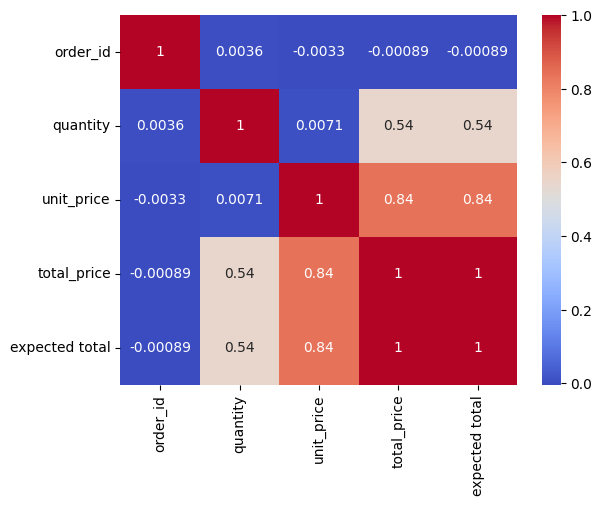

In [191]:
sns.heatmap(df.select_dtypes('number').corr(),annot=True, cmap="coolwarm")

In [192]:
df.head()

,order_id,pizza_name_id,quantity,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name,expected total
0,1,hawaiian_m,1,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza,13.25
1,2,classic_dlx_m,1,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza,16.00
2,2,five_cheese_l,1,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza,18.50
3,2,ital_supr_l,1,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza,20.75
4,2,mexicana_m,1,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza,16.00


In [193]:
le = LabelEncoder()

In [194]:
df['pizza_size'] = le.fit_transform(df['pizza_size'])

In [195]:
categorical_columns = df.select_dtypes(include=['object']).columns

In [196]:
categorical_columns = [col for col in df.columns if df[col].dtype == 'object']

In [197]:
categorical_columns

['pizza_name_id', 'pizza_category', 'pizza_ingredients', 'pizza_name']

In [198]:
for col in categorical_columns:
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

In [199]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])
        df[column] = le.fit_transform(df[column])

In [200]:
# Check if the 'Order Date' column exists before attempting to drop it.
if 'Order Date' in df.columns:
    df.drop('Order Date', axis=1, inplace=True)
else:
    print("Column 'Order Date' not found in the DataFrame.")

Column 'Order Date' not found in the DataFrame.


In [201]:
df.drop('pizza_name', axis=1, inplace=True)

In [202]:
df.drop('pizza_category', axis=1, inplace=True)

In [203]:
df = pd.get_dummies(df)
df_encoded = pd.get_dummies(df).astype(int)

In [204]:
df.head()

,order_id,pizza_name_id,quantity,unit_price,total_price,pizza_size,pizza_ingredients,expected total
0,1,27,1,13.25,13.25,1,23,13.25
1,2,18,1,16.00,16.00,1,20,16.00
2,2,20,1,18.50,18.50,0,17,18.50
3,2,32,1,20.75,20.75,0,4,20.75
4,2,42,1,16.00,16.00,1,31,16.00


In [205]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [206]:
X = df[['quantity', 'pizza_ingredients']]
y = df['pizza_size']

In [207]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [208]:
ml = RandomForestClassifier (n_estimators= 300)

In [209]:
ml.fit (X_train, y_train)

RandomForestClassifier(n_estimators=300)

In [210]:
y_pred = ml.predict(X_test)

In [211]:
accuracy_score(y_test, y_pred)*100

50.678733031674206